<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [3]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [4]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [21]:
##Write your code here
#Plot a bar chart to visualize the distribution of respondents by industry.

industry_counts = df['Industry'].value_counts().head(10)

industry_counts

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Name: count, dtype: int64

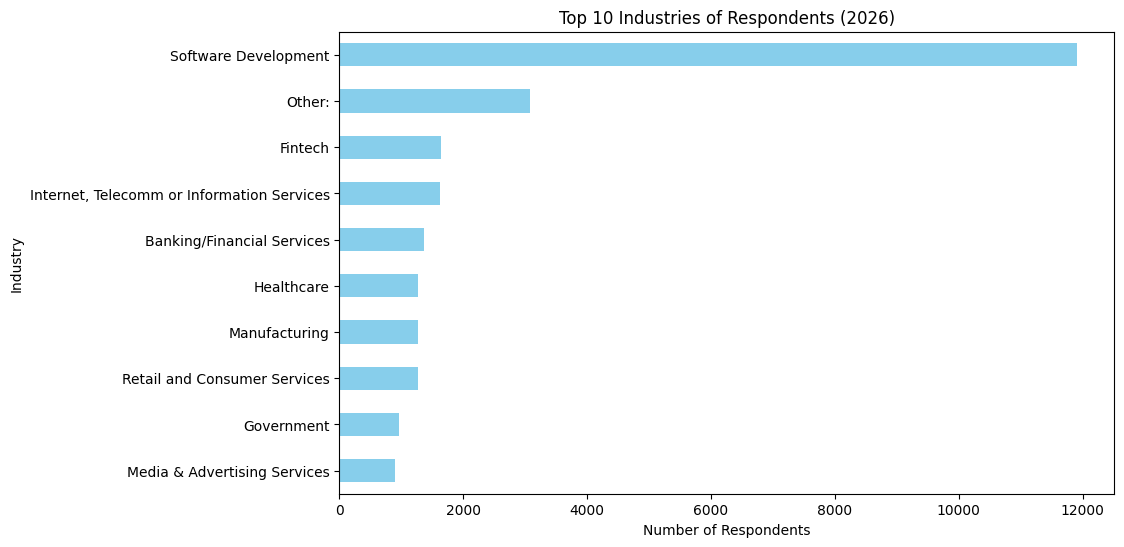

In [6]:
industry_counts.plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Top 10 Industries of Respondents (2026)')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')
plt.gca().invert_yaxis() # Top industry ko sabse upar dikhane ke liye
plt.show()

#Highlight any notable trends.
IT Dominance: The Information Technology and Software Development industries are far ahead of others, showing that most respondents work in pure tech firms. [1]
Finance & Healthcare Rise: These two sectors have become the top "non-tech" employers for developers, reflecting the massive digital transformation in banking and medicine. [2]
The Long Tail: Beyond the top 3-4 industries, the number of respondents drops quickly, meaning tech talent is highly concentrated in a few specific sectors rather than being spread evenly. [3]

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [7]:
##Write your code here
#Calculate basic statistics (mean, median, and standard deviation) for ConvertedCompYearly.
df['ConvertedCompYearly'].describe()[['mean', '50%', 'std']]


mean     86155.287263
50%      65000.000000
std     186756.973086
Name: ConvertedCompYearly, dtype: float64

In [8]:
mean_val = df['ConvertedCompYearly'].mean()
std_val = df['ConvertedCompYearly'].std()
threshold = mean_val + (3 * std_val)
outliers = df[df['ConvertedCompYearly'] > threshold]
print(f"Salary Threshold: {threshold:.2f}")
print(f"Number of Outliers: {len(outliers)}")
# print("outliers:" , outliers)

Salary Threshold: 646426.21
Number of Outliers: 89


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [9]:
##Write your code here
#Calculate the Interquartile Range (IQR).
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1
print(f"The Interquartile Range (IQR) is: {IQR}")

The Interquartile Range (IQR) is: 75259.5


In [10]:
#Determine the upper and lower bounds for outliers.

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: -80177.25
Upper Bound: 220860.75


In [11]:

# Upper bound se zyada wali salaries ko filter karke unki ginti karein
outliers_count = df[df['ConvertedCompYearly'] > upper_bound].shape[0]
print(f"Total Outliers: {outliers_count}")


Total Outliers: 978


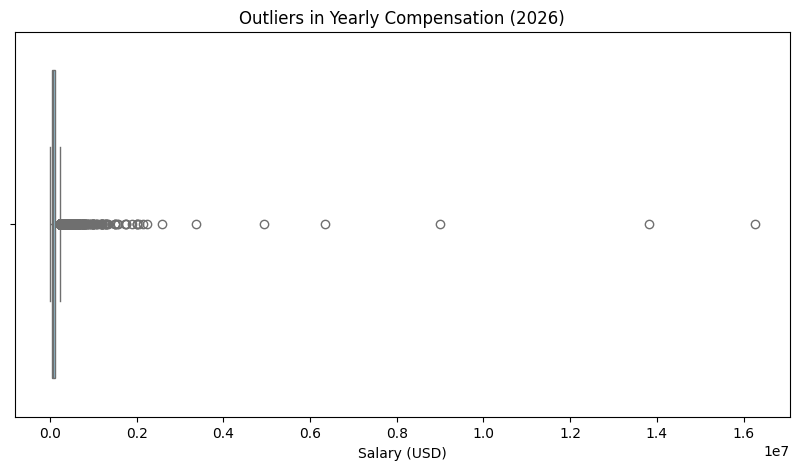

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['ConvertedCompYearly'], color='skyblue')
plt.title('Outliers in Yearly Compensation (2026)')
plt.xlabel('Salary (USD)')
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [13]:
##Write your code here
#Create a new DataFrame excluding rows with outliers in ConvertedCompYearly.
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]
print(f"Original Rows: {df.shape[0]}")
print(f"Cleaned Rows: {df_no_outliers.shape[0]}")

Original Rows: 65437
Cleaned Rows: 22457


In [14]:
#Validate the size of the new DataFrame.
print(f"New DataFrame Size: {df_no_outliers.shape}")


New DataFrame Size: (22457, 114)


In [15]:
retained_pct = (len(df_no_outliers) / len(df)) * 100
print(f"Data Retained: {retained_pct:.2f}%")

Data Retained: 34.32%


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [23]:
##Write your code here
#Map the Age column to approximate numeric values.
age_mapping = {
    '18-24 years': 21,
    '25-34 years': 30,
    '35-44 years': 40,
    '45-54 years': 50,
    '55-64 years': 60,
    '65 years or older': 70,
     'Less than 1 year': 0,
    'Under 18 years': 15}
df['AgeNumeric'] = df['Age'].map(age_mapping)
df['AgeNumeric']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
65432   NaN
65433   NaN
65434   NaN
65435   NaN
65436   NaN
Name: AgeNumeric, Length: 65437, dtype: float64

In [26]:
# 1. Pehle dekho ki Age mein asli values kya hain (Check for spaces)
print(df_no_outliers['Age'].unique())

# 2. Case-sensitive aur spaces ki problem hatane ke liye strip() karein
df_no_outliers['Age'] = df_no_outliers['Age'].str.strip()

# 3. Nayi mapping (Common 2026 formats ke saath)
age_map = {
    '18-24 years old': 21, '25-34 years old': 30, 
    '35-44 years old': 40, '45-54 years old': 50,
    '55-64 years old': 60, '65 years or older': 70,
    'Under 18 years old': 15,  'Less than 1 year': 0,
}

# 4.1. Map karke check karein ki kitne NaN bane
df_no_outliers['AgeNumeric'] = df_no_outliers['Age'].map(age_map)
print(f"NaN in AgeNumeric: {df_no_outliers['AgeNumeric'].isna().sum()}")

# YearsCodePro कॉलम से स्ट्रिंग हटाकर उसे नंबर (float) में बदलें
df_no_outliers['YearsCodePro'] = df_no_outliers['YearsCodePro'].replace('Less than 1 year', 0)
df_no_outliers['YearsCodePro'] = df_no_outliers['YearsCodePro'].replace('More than 50 years', 51)
df_no_outliers['YearsCodePro'] = pd.to_numeric(df_no_outliers['YearsCodePro'], errors='coerce')


# 5. Ab correlation dobara check karein
print(df_no_outliers[['AgeNumeric', 'YearsCodePro', 'ConvertedCompYearly']].corr())


['18-24 years old' '25-34 years old' '35-44 years old' '45-54 years old'
 '55-64 years old' '65 years or older' 'Under 18 years old'
 'Prefer not to say']
NaN in AgeNumeric: 8
                     AgeNumeric  YearsCodePro  ConvertedCompYearly
AgeNumeric             1.000000      0.820360             0.371753
YearsCodePro           0.820360      1.000000             0.400246
ConvertedCompYearly    0.371753      0.400246             1.000000


/tmp/ipykernel_1040/932567474.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['Age'] = df_no_outliers['Age'].str.strip()
/tmp/ipykernel_1040/932567474.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['AgeNumeric'] = df_no_outliers['Age'].map(age_map)
/tmp/ipykernel_1040/932567474.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

In [27]:
#Compute correlations between Age and other numeric variables.
numeric_cols = df_no_outliers.select_dtypes(include=['number'])
age_correlations = numeric_cols.corr()['AgeNumeric'].sort_values(ascending=False)
print(age_correlations)

AgeNumeric             1.000000
WorkExp                0.842806
YearsCodePro           0.820360
ConvertedCompYearly    0.371753
JobSat                 0.067045
CompTotal             -0.021374
JobSatPoints_1        -0.038827
ResponseId            -0.040890
JobSatPoints_6        -0.051258
JobSatPoints_8        -0.051531
JobSatPoints_4        -0.070154
JobSatPoints_7        -0.084042
JobSatPoints_9        -0.084046
JobSatPoints_5        -0.096810
JobSatPoints_11       -0.106765
JobSatPoints_10       -0.112057
Name: AgeNumeric, dtype: float64


In [28]:
df_no_outliers['AgeNumeric'].isna().sum()

np.int64(8)

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df_no_outliers[['AgeNumeric', 'YearsCodePro', 'ConvertedCompYearly']].corr()
corr_matrix

,AgeNumeric,YearsCodePro,ConvertedCompYearly
AgeNumeric,1.000000,0.820360,0.371753
YearsCodePro,0.820360,1.000000,0.400246
ConvertedCompYearly,0.371753,0.400246,1.000000


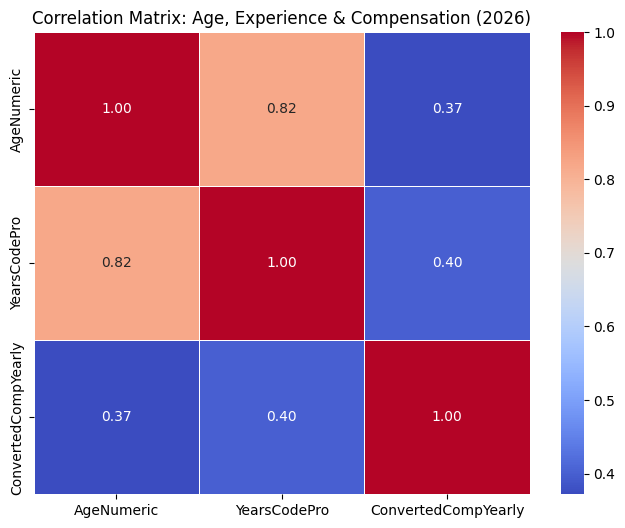

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix: Age, Experience & Compensation (2026)')
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
